#  Verim Tahmini — Süt Bileşenleri Deneyi

**Amaç:** Bir önceki notebook'ta (03) "adil" özelliklerle süt verimi tahmini
düşük çıkmıştı (R² ≈ 0.10). Bu deneyde, kasıtlı olarak süt bileşenlerini
(yağ/protein/laktoz) ekleyerek R²'nin fırlayıp fırlamadığını test ediyoruz.

**Beklenti:** Bileşenler süt verimiyle doğrudan bağlı olduğu için R² yükselecek.
Ancak bu "kopya" sayılır — çünkü bu ölçümler süt üretildikten SONRA elde edilir,
yani gerçek bir önden tahmin değildir. Bu deney, önceki bulguyu kanıtlamak için.

In [1]:
from google.colab import files
yuklenen = files.upload()

Saving Dataset_cow_performance.xlsx to Dataset_cow_performance.xlsx


yine öncelikle indirdiğimiz veri setimizi colabımıza bağlıyoruz.


In [2]:
import pandas as pd

df = pd.read_excel("Dataset_cow_performance.xlsx", sheet_name="Dataset")

# Bu sefer sadece kimlik/gereksiz sütunları at — süt bileşenlerini TUTUYORUZ
atilacaklar = ["ID", "ID Cow", "ID cow with Codex", "Calving Date",
               "ID Breed", "Farm ID", "Stable ID",
               "Method of Performance Control Database", "GZW/SIH"]

df_temiz = df.drop(columns=atilacaklar)

# Irk gruplama (03'teki gibi)
en_sik = df_temiz["Breed"].value_counts().nlargest(4).index
df_temiz["Breed_grup"] = df_temiz["Breed"].apply(lambda x: x if x in en_sik else "Diger")
df_temiz = df_temiz.drop(columns=["Breed"])

# One-Hot
df_hazir = pd.get_dummies(df_temiz, columns=["Breed_grup", "Calving Season"], drop_first=True)

print("Sütunlar:", df_hazir.columns.tolist())
print("Boyut:", df_hazir.shape)

Sütunlar: ['Year of Lactation', 'Parity', 'CalvInt', 'SP', 'MY (kg)', 'F (kg)', 'P (kg)', 'L (kg)', 'F (%)', 'P (%)', 'L (%)', 'Breed_grup_C50R', 'Breed_grup_C85R', 'Breed_grup_Diger', 'Breed_grup_R100', 'Calving Season_2', 'Calving Season_3', 'Calving Season_4']
Boyut: (723, 18)


Burda da asıl yaptıgımız kritik nokta kanıtlamaya çalıştıgımız şey.Bu sefer F/P/L değerlerini atılacaklar listesine eklemedik.Sütunlarımızdan bu sefer çıkammaıl olucak bir sonraki kod hücremizde "mae,r2" degerlerini hesaplayaıp gerçekten değerlerimiz değişecek mi kontrol edicez .Ama 03 de dediğimiz gibi bi tık kopya çekmiş olacak modelimiz .Ama bizim amacımız sadece 03 ü kanıtlamak :))) kopya çektirtmek değil yani.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df_hazir.drop("MY (kg)", axis=1)
y = df_hazir["MY (kg)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

tahminler = model.predict(X_test)
mae = mean_absolute_error(y_test, tahminler)
r2 = r2_score(y_test, tahminler)

print("Bileşenli MAE:", round(mae, 2), "kg")
print("Bileşenli R²:", round(r2, 3))
print()
print("Karşılaştırma:")
print("03 (bileşensiz, adil) → R²: 0.097")
print("04 (bileşenli, kopya) → R²:", round(r2, 3))

Bileşenli MAE: 46.45 kg
Bileşenli R²: 0.997

Karşılaştırma:
03 (bileşensiz, adil) → R²: 0.097
04 (bileşenli, kopya) → R²: 0.997


Bu deneyde neyi görmüş olduk: R² değerim 0.097'den 0.997'ye yükseldi — bu neredeyse
kusursuz bir sonuç. Bu Colab'da yapmaya çalıştığımız şey de zaten tam olarak bunu
görmekti.


Peki bu ne demek? İyi gibi görünüyor ama aslında bu bir uyarı: modelim kopya çekti.
Süt bileşenlerini (yağ, protein, laktoz) modele verdiğimiz için, model bu verileri
kullanarak cevabı adeta geri okudu. Böylece 03'teki olumsuz bulguyu da kanıtlamış
olduk: yağ ve protein sütunlarını çıkarmamış olmak, modelin bu verileri kullanarak
"kopya çekmesi" anlamına geliyor. Model bize şunu söylüyor: "Benim eğitilmeme gerek
yok, elimdeki bileşen verileriyle mükemmele yakın sonuç çıkarabilirim." Ama bu, bizim
istediğimiz bir şey değil — çünkü gerçek hayatta bu bileşenler süt sağıldıktan SONRA
ölçülüyor, yani önden tahminde kullanılamaz.


Bu deneyle `**data leakage (veri sızıntısı)** `kavramını canlı olarak gösterdik: hedefe
çok yakın, hedefin bir parçası olan bir özelliği modele verirsek, sahte bir
mükemmellik elde ederiz.

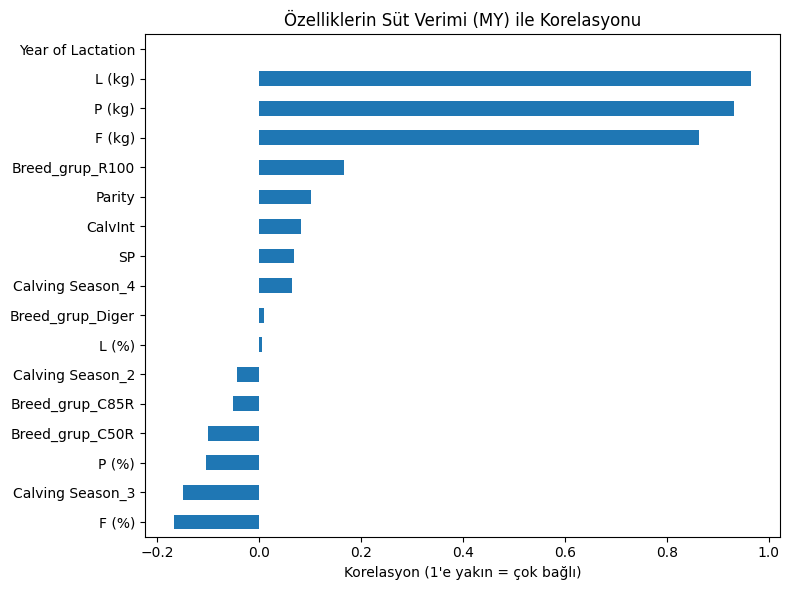

F (%)               -0.167367
Calving Season_3    -0.148822
P (%)               -0.103482
Breed_grup_C50R     -0.099551
Breed_grup_C85R     -0.051129
Calving Season_2    -0.043463
L (%)                0.006092
Breed_grup_Diger     0.009322
Calving Season_4     0.065114
SP                   0.069509
CalvInt              0.081845
Parity               0.102905
Breed_grup_R100      0.167912
F (kg)               0.863284
P (kg)               0.932090
L (kg)               0.965675
Year of Lactation         NaN
Name: MY (kg), dtype: float64


In [4]:
import matplotlib.pyplot as plt

# Her özelliğin hedefle (MY) korelasyonu
korelasyon = df_hazir.corr()["MY (kg)"].drop("MY (kg)").sort_values()

plt.figure(figsize=(8, 6))
korelasyon.plot(kind="barh")
plt.title("Özelliklerin Süt Verimi (MY) ile Korelasyonu")
plt.xlabel("Korelasyon (1'e yakın = çok bağlı)")
plt.tight_layout()
plt.show()

print(korelasyon)

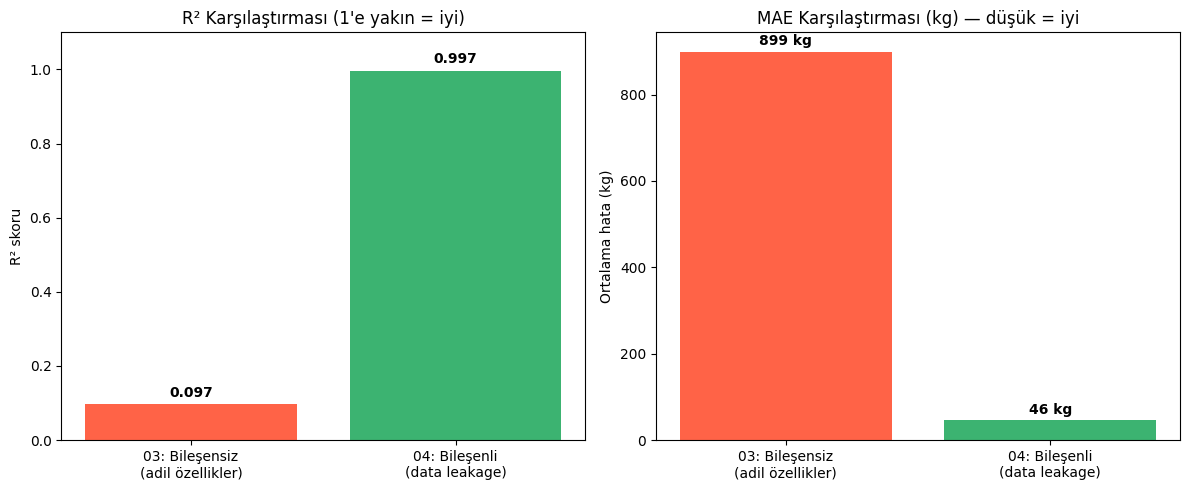

In [5]:
import matplotlib.pyplot as plt

# İki denemenin sonuçları
modeller = ["03: Bileşensiz\n(adil özellikler)", "04: Bileşenli\n(data leakage)"]
r2_skorlari = [0.097, 0.997]
mae_skorlari = [899, 46]

# Yan yana iki grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sol: R² karşılaştırması
renkler = ["tomato", "mediumseagreen"]
ax1.bar(modeller, r2_skorlari, color=renkler)
ax1.set_title("R² Karşılaştırması (1'e yakın = iyi)")
ax1.set_ylabel("R² skoru")
ax1.set_ylim(0, 1.1)
for i, v in enumerate(r2_skorlari):
    ax1.text(i, v + 0.02, str(v), ha="center", fontweight="bold")

# Sağ: MAE karşılaştırması
ax2.bar(modeller, mae_skorlari, color=renkler)
ax2.set_title("MAE Karşılaştırması (kg) — düşük = iyi")
ax2.set_ylabel("Ortalama hata (kg)")
for i, v in enumerate(mae_skorlari):
    ax2.text(i, v + 15, str(v) + " kg", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

Bu grafiklerle de yapmaya çalıştığımız şeyi görselleştirelim istedim.Daha net ve bariz bi şekilde kopya çektiğini de gömüş olduk :))))))))))))

##  Kapanış — Data Leakage Deneyi

Bu notebook'ta, bir önceki çalışmanın (03) olumsuz bulgusunu kanıtlamak için bir
deney yaptık: süt bileşenlerini (yağ, protein, laktoz) kasıtlı olarak modele
ekleyip, R²'nin nasıl değiştiğini gözlemledik.

**İzlenen adımlar**
1. Veriyi yükleme ve bu sefer süt bileşenlerini (F/P/L) TUTARAK hazırlama
2. Aynı modeli (LinearRegression) eğitip R²'yi ölçme
3. Sonucu 03 ile karşılaştırma
4. Korelasyon ve karşılaştırma grafikleriyle görselleştirme

**Sonuç**
| Deneme | Özellikler | MAE | R² |
|---|---|---|---|
| 03 | Bileşensiz (adil) | 899 kg | 0.097 |
| 04 | Bileşenli (leakage) | 46 kg | 0.997 |

**Temel Bulgu**
Süt bileşenlerini eklediğimizde R² 0.097'den 0.997'ye fırladı. Ancak bu, iyi bir
model değil; bir **data leakage (veri sızıntısı)** örneğidir. Bileşenler süt
üretildikten sonra ölçülen, hedefe doğrudan bağlı değerler olduğu için model
"kopya çekiyor" — verimin parçalarını toplayıp geri veriyor. Gerçek hayatta bu
model kullanılamaz, çünkü çiftçi tahmin isterken bu bileşenler henüz ölçülmemiş
olur.

Bu deney, 03'teki bulguyu doğruladı: gerçek bir verim tahmini için, hedefe sızmayan
ama şu an veride bulunmayan özelliklere (yem, sağlık, bakım) ihtiyaç var.